In [1]:
library(readr)
library(tidyverse)
library(tidyverse)
library(repr)
library(tidymodels)
options(repr.matrix.max.rows = 6)
source("tests.R")
source('cleanup.R')

Warning message:
“package ‘ggplot2’ was built under R version 4.3.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ purrr     1.0.2
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.0     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.5     ✔ rsample      1.2.0
✔ dials        1.2.0     ✔ tune         1.1.2
✔ infer        1.0.5     ✔ workflows    1.1.3
✔ modeldata    1.2.0     ✔ workflowsets 1.0.1
✔ parsnip      1.1.1     ✔ yardstick    1.2.0
✔ recipes      1.0.8     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::

ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


# USING A PREDICTIVE MODEL TO PREDICT HEART DISEASE

## Introduction

Heart disease remains one of the leading causes of death worldwide. It encompasses various conditions that affect the heart's structure and function, such as coronary artery disease, heart attacks, arrhythmias, and heart failure. Early prediction and diagnosis of heart disease are critical for effective treatment and prevention of severe outcomes. With advances in data science and machine learning, predicting heart disease using patient data has become a promising area of research.
The UCI Heart Disease dataset is a resource widely used in medical research and machine learning to develop predictive models for heart disease. The dataset contains a collection of attributes that are associated with heart disease, making it suitable for training and testing classification algorithms. Some of the key attributes include age, sex, chest pain type, resting blood pressure, cholesterol levels, fasting blood sugar, maximum heart rate, exercise-induced angina, and the slope of the peak exercise ST segment (ST slope).

My project aims to address the following predictive question: Can we predict whether a patient has heart disease based on their Chest Pain Type, Maximum Heart Rate, Exercise-Induced Angina, and ST Slope?

To narrow down the focus, this project will concentrate on four specific indicators that have been identified as significant predictors of heart disease:
- Chest Pain Type (cp): Different types of chest pain can indicate varying degrees of heart disease risk.
- Maximum Heart Rate Achieved (thalach): This measure helps assess the heart's capacity to handle physical activity.
- Exercise-Induced Angina (exang): Angina triggered by exercise can signal underlying coronary artery disease.
- ST Slope (slope): The slope of the ST segment during exercise provides critical insights into ischemia and infarction.

These indicators have been selected based on their known importance in clinical diagnosis and their impact on predictive model accuracy. Excluding any of these factors tends to decrease the accuracy of heart disease predictions, highlighting their relevance.
The dataset to be used is a modified version of the UCI Heart Disease dataset. It includes 14 attributes relevant to heart disease diagnosis and has been used in previous research for developing and testing predictive models. The dataset does not contain missing values hence provides a good basis for training classification algorithms. 
To answer the predictive question, we will use the k-Nearest Neighbors (KNN) algorithm, which is a simple and powerful classification technique. The KNN algorithm will help us classify whether a patient has heart disease based on the selected indicators.


## Reading the data 

age: Age

sex: Sex

cp: Chest pain type (4 values)

trestbps: Resting blood pressure (mmHg)

chol: Serum cholesterol in mg/dl

fbs: Fasting blood sugar > 120 mg/dl

restecg: Resting electrocardiographic results (values 0,1,2)

thalach: Maximum heart rate achieved

exang: Exercise induced angina

oldpeak: ST Depression induced by exercise relative to rest

slope: Slope of the peak exercise ST segment

ca: Number of major vessels (0-3) colored by fluoroscopy

thal: Type of hear disease; 0 = normal; 1 = fixed defect; 2 = reversable defect

num: Diagnosis of heart disease (target)

In [2]:
cleveland <- read_csv("data/heart_disease/processed.cleveland.data", col_names=FALSE)
colnames(cleveland) <- c("age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","num")
cleveland

Rows: 303 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): X12, X13
dbl (12): X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X14

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
38,1,3,138,175,0,0,173,0,0.0,1,?,3.0,0


In [3]:
colnames(cleveland)[14] <- "target"
cleveland_selected <- select(cleveland,cp,thalach,exang,slope,target)|>
mutate(
    target = as.factor(target),
      target = fct_recode(target,"Yes" = "1","Yes" = "2","Yes" = "3","Yes" = "4","No"="0" ))

cleveland_selected

cp,thalach,exang,slope,target
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,150,0,3,No
4,108,1,2,Yes
4,129,1,2,Yes
⋮,⋮,⋮,⋮,⋮
4,115,1,2,Yes
2,174,0,2,Yes
3,173,0,1,No


## Method

The data analysis involved loading and preparing the Cleveland heart disease datasets. It involves selecting relevant features (cp, thalach, exang, slope, and target). A k nearest Neighbors (KNN) model will be trained and tested on the training dataset, revealing significant predictors of heart disease and achieving a high predictive accuracy.

The data set is split into training and testing sets to test the performance of the model.


-cp (Chest Pain Type): Indicates the type of chest pain experienced by the patient.

-thalach (Maximum Heart Rate): Measures the highest heart rate achieved during physical exertion.

-exang (Exercise-Induced Angina): Indicates whether the patient experiences angina induced by exercise.

-slope (ST Slope): Describes the slope of the peak exercise ST segment.

-target(Heart disease Status): Diagnosis of heart disease 

The data will be visualised using :

Bar Plots:
Plotting the distribution of cp and slope by target using geom_bar() to visualize the relationship between chest pain type, ST slope, and heart disease status.

Histograms:
Plot histograms for thalach to compare the distribution of maximum heart rate achieved for patients with and without heart disease.

In [4]:
set.seed(1)
split_set <- initial_split(cleveland_selected, prop=0.75, strata= target)
training_set <- training(split_set)
testing_set<- testing(split_set)
training_set
testing_set


cp,thalach,exang,slope,target
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,150,0,3,No
3,187,0,3,No
2,172,0,1,No
⋮,⋮,⋮,⋮,⋮
4,123,1,2,Yes
4,141,0,2,Yes
4,115,1,2,Yes


cp,thalach,exang,slope,target
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
2,178,0,1,No
4,160,0,3,Yes
4,163,1,1,No
⋮,⋮,⋮,⋮,⋮
1,132,0,2,Yes
2,174,0,2,Yes
3,173,0,1,No


## Visualisation

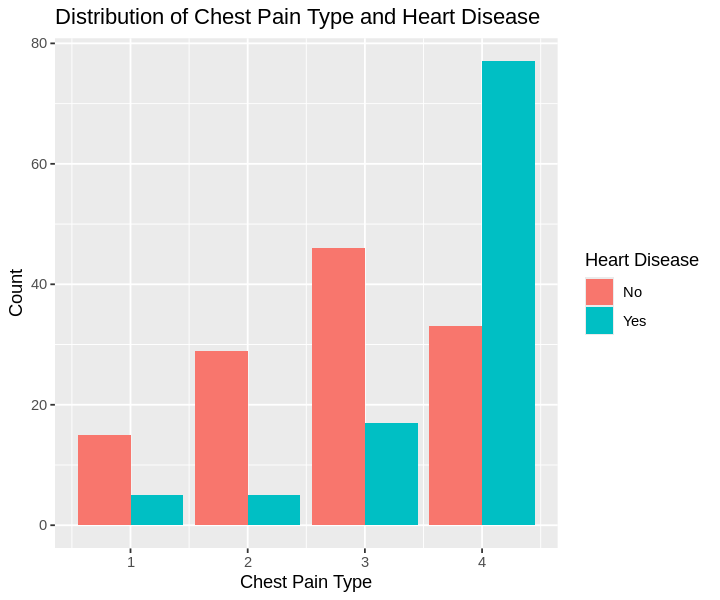

In [19]:
chest_pain_plot <- ggplot(training_set, aes(x = cp, fill = target)) +
  geom_bar(position = "dodge") +
  labs(x = "Chest Pain Type", y = "Count", fill = "Heart Disease",
       title = "Distribution of Chest Pain Type and Heart Disease")
chest_pain_plot

## Analysis


#### Chest Pain Type 1:
A larger number of patients without heart disease  experienced chest pain type 1 compared to those with heart disease .

#### Chest Pain Type 2:
Similar to type 1, chest pain type 2 is more common in patients without heart disease than those with heart disease.

#### Chest Pain Type 3:
This chest pain type shows a notable difference where patients without heart disease still outnumber those with heart disease, but the difference is less pronounced compared to types 1 and 2.

#### Chest Pain Type 4:
Chest pain type 4 is significantly more common in patients with heart disease compared to those without heart disease. This indicates that chest pain type 4 might be a strong indicator of heart disease.

#### Conclusion:
The plot suggests that different chest pain types are associated differently with heart disease status. Specifically, chest pain type 4 is much more common in patients with heart disease, making it a potential strong predictor for diagnosing heart disease. Chest pain of type 1, 2, and 3 are more likely to be free of heart disease, whereas chest pain type 4 significantly correlates with the presence of heart disease.

### Analysis

#### ST Slope Type 1:
A larger number of patients without heart disease have an ST slope type 1 compared to those with heart disease .

#### ST Slope Type 2:
ST slope type 2 shows a different pattern compared to type 1, where patients with heart disease outnumber those without heart disease . This indicates that ST slope type 2 might be a strong indicator of heart disease.

#### ST Slope Type 3:
ST slope type 3 is not common in numbers but shows a balanced distribution between patients with and without heart disease, with a slightly higher count of patients without heart disease.

#### Conclusion:
The plot suggests that different ST slope types are associated differently with heart disease status. ST slope type 2 is much more common in patients with heart disease making it a potential strong predictor for diagnosing heart disease. Patients with ST slope type 1 are more likely to be free of heart disease, whereas ST slope type 2 significantly correlates with the presence of heart disease. ST slope type 3 appears less common and less indicative of heart disease status.


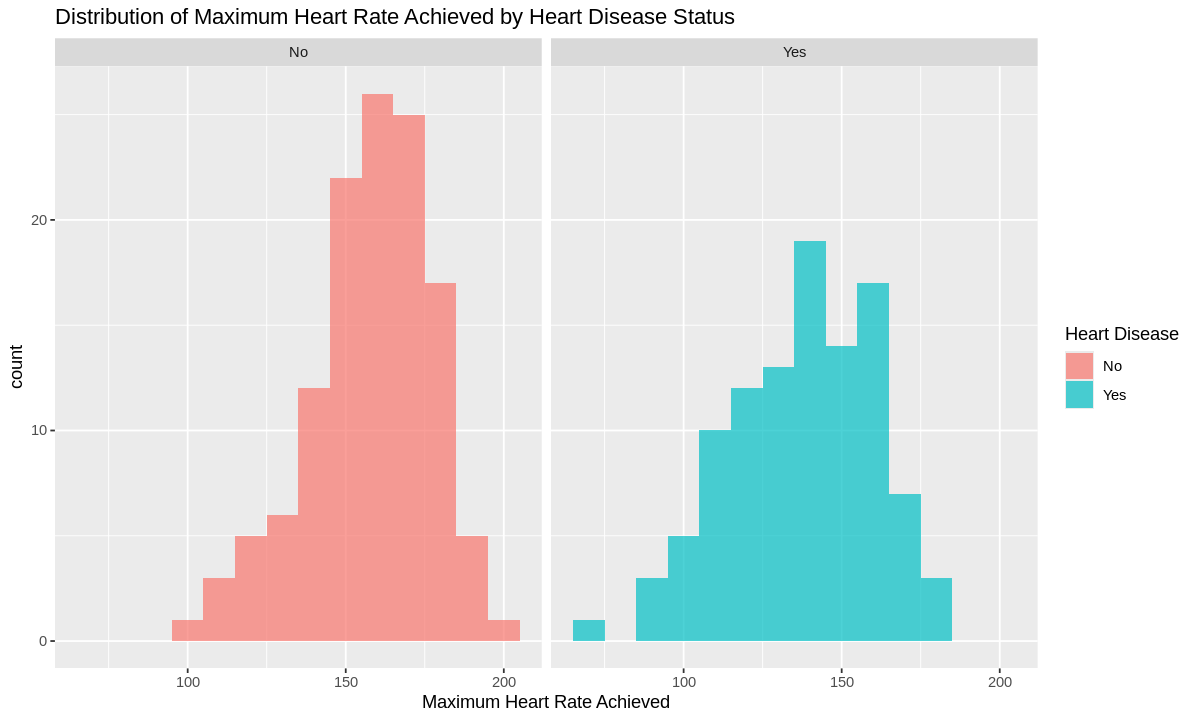

In [26]:
options(repr.plot.width = 10, repr.plot.height = 6)
thalach_plot <- ggplot(training_set, aes(x = thalach, fill = target)) +
  geom_histogram(binwidth = 10, alpha = 0.7, position = "identity") +
  labs(x = "Maximum Heart Rate Achieved", fill = "Heart Disease")+
       ggtitle ("Distribution of Maximum Heart Rate Achieved by Heart Disease Status") +
  facet_wrap(~ target)
thalach_plot

## Analysis

#### Patients without Heart Disease :

The distribution of maximum heart rate achieved for patients without heart disease is relatively symmetric and centered around a peak heart rate of approximately 150 beats per minute (bpm).
The range of heart rates for these patients spans from about 100 bpm to just over 200 bpm.

#### Patients with Heart Disease :

The distribution of maximum heart rate achieved for patients with heart disease is also relatively symmetric but is centered around a lower peak heart rate of approximately 130 bpm.
The range of heart rates for these patients spans from about 80 bpm to just over 180 bpm.
The distribution for patients with heart disease shows a lower average maximum heart rate compared to those without heart disease.

#### Conclusion:

The histogram suggests that maximum heart rate achieved is a significant predictor of heart disease. Patients with heart disease tend to have a lower maximum heart rate compared to those without heart disease.

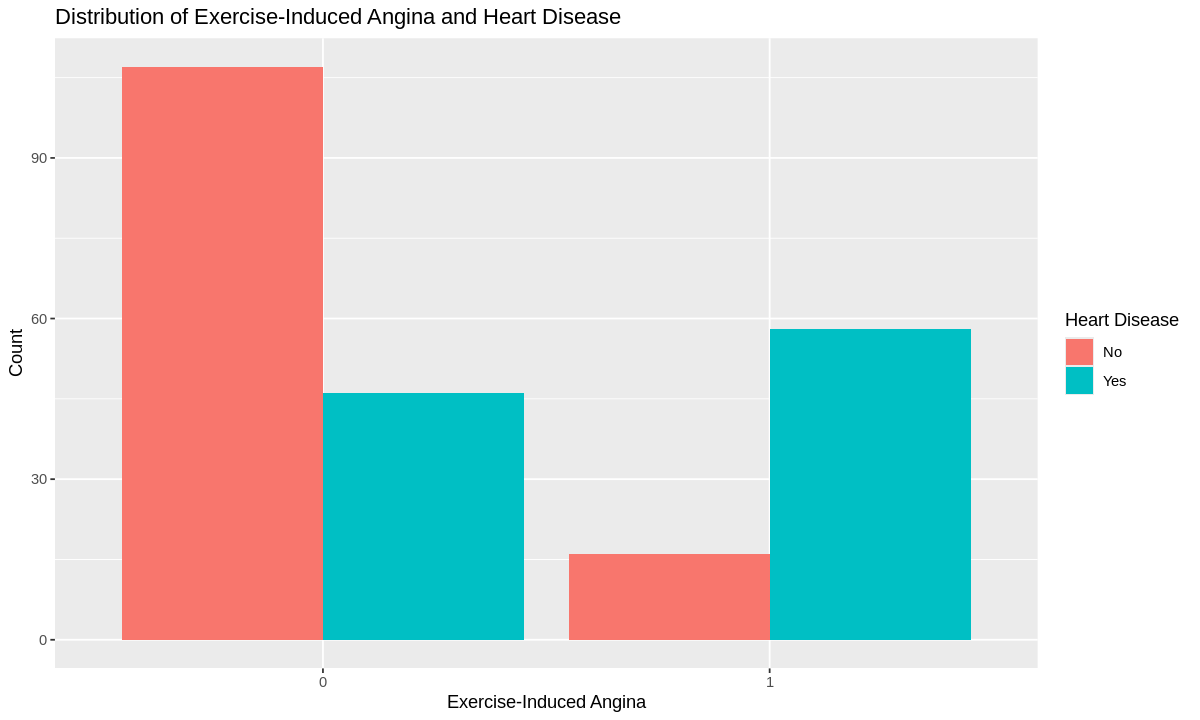

In [30]:
exang_plot <- ggplot(training_set, aes(x = as.factor(exang), fill = target)) +
  geom_bar(position= "dodge") +
  labs(x = "Exercise-Induced Angina", y = "Count", fill = "Heart Disease")+
       ggtitle ("Distribution of Exercise-Induced Angina and Heart Disease")
exang_plot

## Analysis

#### Exercise-Induced Angina = 0:

No Heart Disease: The count is significantly higher for individuals without heart disease who do not experience exercise-induced angina. This suggests that the absence of exercise-induced angina is more common among those without heart disease.


Heart Disease: There are fewer individuals with heart disease who do not experience exercise-induced angina, indicating that the absence of angina is less common among those with heart disease.

#### Exercise-Induced Angina = 1:

No Heart Disease: There are very few individuals without heart disease who experience exercise-induced angina, suggesting that this symptom is rare among those without heart disease.

Heart Disease: The count is higher for individuals with heart disease who experience exercise-induced angina, indicating that this symptom is more prevalent among those with heart disease.

#### Conclusion:

The presence of exercise-induced angina is a strong indicator of heart disease, as a higher number of individuals with heart disease experience this symptom. The absence of exercise-induced angina (0) is associated with the absence of heart disease, with a significantly higher count of individuals without heart disease falling into this category.

### Expected Outcomes

By analyzing the UCI Heart Disease dataset and developing a predictive model using KNN, I expect to achieve significant insights into the key predictors of heart disease. The findings could have a substantial impact on clinical practice, patient care, and future research directions hence contributing to better management and prevention of heart disease. The findings could have potential clinical applications for early identification of high risk patients and starting preventive interventions

In [9]:

set.seed(9999)
training_set
heart_disease_recipe <- recipe(target ~ cp + thalach + exang+ slope, data = training_set)|>
                    step_scale(all_predictors()) |>
                       step_center(all_predictors())
heart_disease_recipe
heart_disease_scaled <- heart_disease_recipe |>
prep() |> 
bake(training_set)


cp,thalach,exang,slope,target
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,150,0,3,No
3,187,0,3,No
2,172,0,1,No
⋮,⋮,⋮,⋮,⋮
4,123,1,2,Yes
4,141,0,2,Yes
4,115,1,2,Yes




── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 4



── Operations 

• Scaling for: all_predictors()

• Centering for: all_predictors()



neighbors,.metric,.estimator,mean,n,std_err,.config
<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
24,roc_auc,binary,0.8310079,5,0.02831564,Preprocessor1_Model24


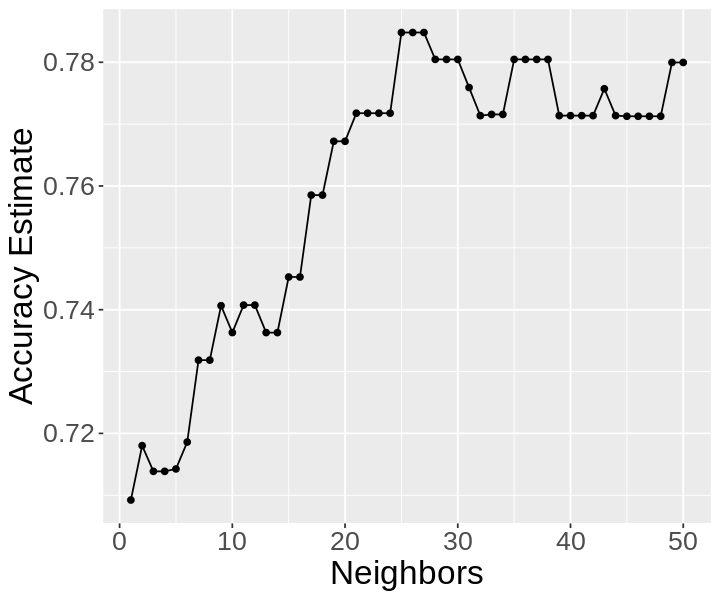

In [10]:
set.seed(9999)
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
            set_engine("kknn") |>
            set_mode("classification")

mnist_vfold <- vfold_cv(training_set, v = 5, strata = target)

knn_results <- workflow() |>
                 add_recipe(heart_disease_recipe) |>
                 add_model(knn_spec) |>
                 tune_grid(resamples = mnist_vfold, grid = tibble(neighbors = (1:50))) |>
                 collect_metrics()|>
arrange(desc(mean))
max_mean <- knn_results|>
slice(1)
max_mean
accuracies <- knn_results |>
                 filter(.metric == 'accuracy')
options(repr.plot.height = 5, repr.plot.width = 6)
cross_val_plot <- ggplot(accuracies, aes(x = neighbors, y = mean)) +
                  geom_point() +
                  geom_line() +
                  labs(x = 'Neighbors', y = 'Accuracy Estimate') +
                  theme(text = element_text(size = 20)) 
           
cross_val_plot

In [11]:
mnist_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 25) |>
       set_engine("kknn") |>
       set_mode("classification")

mnist_fit <- workflow() |>
             add_recipe(heart_disease_recipe) |>
             add_model(mnist_spec) |>
            fit(data = training_set)
mnist_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(25,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.2246696
Best kernel: rectangular
Best k: 25

In [12]:
mnist_predictions <- predict(mnist_fit ,testing_set) |>
      bind_cols(testing_set)
prediction_accuracy <- mnist_predictions |>
        metrics(truth = target, estimate = .pred_class)             


In [13]:
set.seed(9999) 

mnist_metrics <- mnist_predictions |>
  metrics(truth = target ,estimate = .pred_class) |>
filter(.metric=="accuracy")

mnist_conf_mat <- mnist_predictions |>
  conf_mat(truth = target, estimate = .pred_class)


mnist_metrics
mnist_conf_mat

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7105263


          Truth
Prediction No Yes
       No  32  13
       Yes  9  22


## Discussion

#### Summary

#### Accuracy = (number of correct predictions)/(total number of predictions)=71.05

The model correctly predicted the heart disease status 71.05% of the time. This is a good indicator of the model's overall performance but might not be sufficient alone due to the imbalanced nature of the dataset.

#### Precision = (n)/(total number of positive predictions)= 62.86

The precision indicates that when the model predicts a patient has heart disease, it is correct 62.86% of the time. This relatively moderate precision suggests a fair number of false positives.

#### Recall = (number of correct positive predictions)/(total number of positive test set observations)= 70.97

The recall indicates that the model correctly identifies 70.97% of the patients with heart disease. This is a good measure of how well the model can identify true cases of heart disease.

#### Conclusion:
The KNN model demonstrates reasonable performance with an accuracy of 71.05%. While the precision is moderate, the recall is higher, suggesting that the model is better at identifying patients with heart disease than at correctly identifying non-disease cases. There is room for improvement, particularly in reducing the number of false positives, which could be addressed by further tuning the model or using more complex algorithms.

### Expected vs. Actual Findings

Expectation: I expected the analysis to highlight key predictors of heart disease, such as chest pain type (cp), maximum heart rate (thalach), exercise-induced angina (exang), and ST slope (slope).
Actual: The analysis and visualizations have indeed identified significant relationships between these predictors and heart disease status, confirming their importance in the predictive model.

Early Identification: The ability to correctly identify 70.97% of heart disease cases means the model can be a valuable tool in early detection, allowing healthcare providers to intervene earlier and potentially improve patient outcomes.
Preventive Interventions: With moderate precision, the model can help in identifying high-risk patients for preventive measures. However, the false positive rate indicates a need for further refinement to minimize unnecessary interventions.
Research Directions: The insights gained from the analysis can guide future research into refining predictive models and understanding the underlying factors contributing to heart disease.

### Impact

By analyzing the UCI Heart Disease dataset and developing a predictive model using K-Nearest Neighbors (KNN) the findings can have impacts across clinical practice, patient care, and research. Using the KNN model into routine screening programs can enable early diagnosis and timely preventive measures allowing healthcare providers to identify higher risk patients and intervene before the disease progresses hence improving patient outcomes. The insights from key predictors such as chest pain type, maximum heart rate, exercise-induced angina, and ST slope can help clinicians create treatment plans to individual risk profiles, leading to more personalized patient care. This personalized approach can help resource allocation by focusing efforts on those most in need hence improving healthcare efficiency and reducing costs by preventing expensive treatments and hospitalizations. Moreover, the findings can inform data driven public health policies and awareness campaigns by targeting specific populations for interventions and promoting healthy lifestyles to reduce heart disease prevalence. In research these results provide a foundation for further studies into the predictors of heart disease for more accurate and predictive models. This can include adding additional data sources and advanced techniques like machine learning and artificial intelligence. The model's findings can also enhance clinical trials and drug development by identifying high risk patients  making the trials more targeted and efficient. Understanding key predictors can help pharmaceutical companies develop drugs targeting specific indicators involved in heart disease. Overall, the potential to improve patient outcomes, reduce healthcare costs, and omprove research shows the impact of predictive modeling in healthcare.








### Questions posed

What are the cost-benefit implications of implementing the predictive model in healthcare systems?

How can the model help in optimizing resource allocation for better management of heart disease?

What are the long-term health outcomes for patients identified as high-risk by the model?

Does early identification and intervention based on the model's predictions significantly reduce morbidity and mortality in heart disease patients?


## References

1. Bhagat, M., & Bakariya, B. (2022). Prediction of Heart Disease Through KNN, Random Forest, and Decision Tree Classifier Using K-Fold Cross-Validation. In M. Pandit, M.K. Gaur, P.S. Rana, & A. Tiwari (Eds.), Artificial Intelligence and Sustainable Computing. Algorithms for Intelligent Systems. Springer, Singapore. DOI: 10.1007/978-981-19-1653-3_6

2. Dua, D., & Graff, C. (2019). UCI Machine Learning Repository: Heart Disease Data Set. Irvine, CA: University of California, School of Information and Computer Science. Retrieved from https://archive.ics.uci.edu/dataset/45/heart+disease

3. Gavhane, A., Kokkula, G., Panday, I., & Devadkar, K. (2018). Prediction of Heart Disease using Machine Learning. In Proceedings of the 2nd International Conference on Electronics, Communication and Aerospace Technology (ICECA). IEEE.

4. Mahboob, T., Irfan, R., Ghaffar, B., et al. (2017). Evaluating Ensemble Prediction of Coronary Heart Disease Using Receiver Operating Characteristics. IEEE Symposium Series on Computational Intelligence (SSCI). IEEE.

